# Diabetes Prediction — Machine Learning Capstone

**Goal:** Predict whether a patient is diagnosed with diabetes using demographic and health-related features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.preprocessing import OneHotEncoder

## 1. Load the Dataset

Load the training and test datasets and inspect the first few rows.

In [2]:
# Load training and test data
df = pd.read_csv('train.csv')
test = pd.read_csv("test.csv")
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [3]:
df.shape

(700000, 26)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                          7

In [5]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Remove ID columns because they are identifiers, not predictive features
df = df.drop('id',axis=1)
test_ids = test['id']
test_df = test.drop('id', axis=1)

In [7]:
test_df.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,45,4,100,4.3,6.8,6.2,25.5,0.84,123,70,...,111,Female,White,Highschool,Middle,Former,Employed,0,0,0
1,35,1,87,3.5,4.6,9.0,28.6,0.88,120,74,...,145,Female,White,Highschool,Middle,Never,Unemployed,0,0,0
2,45,1,61,7.6,6.8,7.0,28.5,0.94,112,71,...,184,Male,White,Highschool,Low,Never,Employed,0,0,0
3,55,2,81,7.3,7.3,5.0,26.9,0.91,114,81,...,128,Male,White,Graduate,Middle,Former,Employed,0,0,0
4,77,2,29,7.3,7.6,8.5,22.0,0.83,131,78,...,133,Male,White,Graduate,Low,Current,Unemployed,0,0,0


## 2. Exploratory Data Analysis

Check data quality, class balance, and relationships between important features and diabetes.

**Data quality checks**  
Check for missing values and duplicate rows before modeling.

In [8]:
# missing value check
df.isnull().sum()

age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
diagnosed_diabetes                    0


In [9]:
# dulpicate value check
df.duplicated().sum()

np.int64(0)

**Target distribution**  
Check whether the diabetes classes are balanced or imbalanced.

In [10]:
# class imbalance check
df['diagnosed_diabetes'].value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

<Axes: xlabel='diagnosed_diabetes', ylabel='count'>

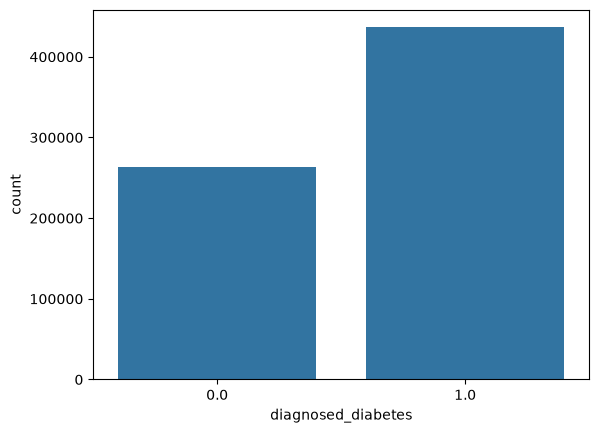

In [11]:
sns.countplot(data=df, x='diagnosed_diabetes')

<Axes: xlabel='age', ylabel='cholesterol_total'>

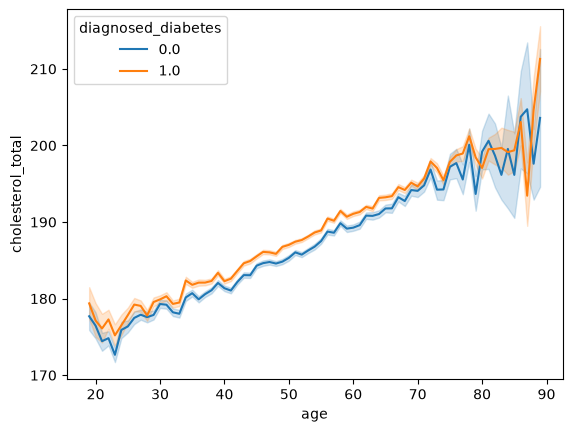

In [12]:
sns.lineplot(data=df,x='age',y='cholesterol_total' , hue='diagnosed_diabetes')

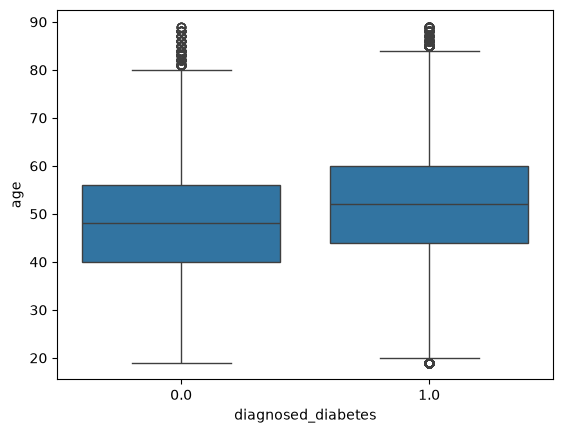

In [13]:
sns.boxplot(data=df,x='diagnosed_diabetes', y='age')
plt.show()

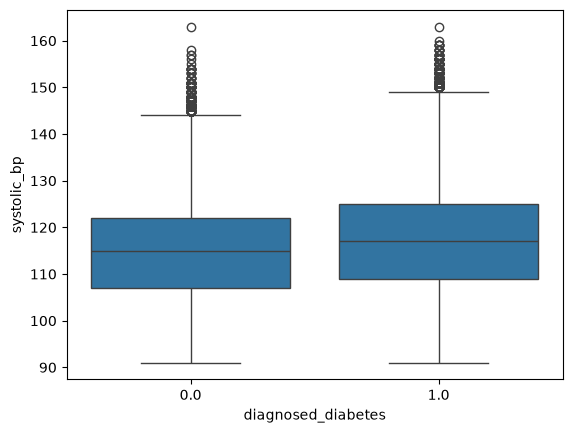

In [14]:
sns.boxplot(data=df,x='diagnosed_diabetes',y='systolic_bp')
plt.show()

**Correlation overview**  
Use correlations as a quick way to inspect relationships between numerical variables.

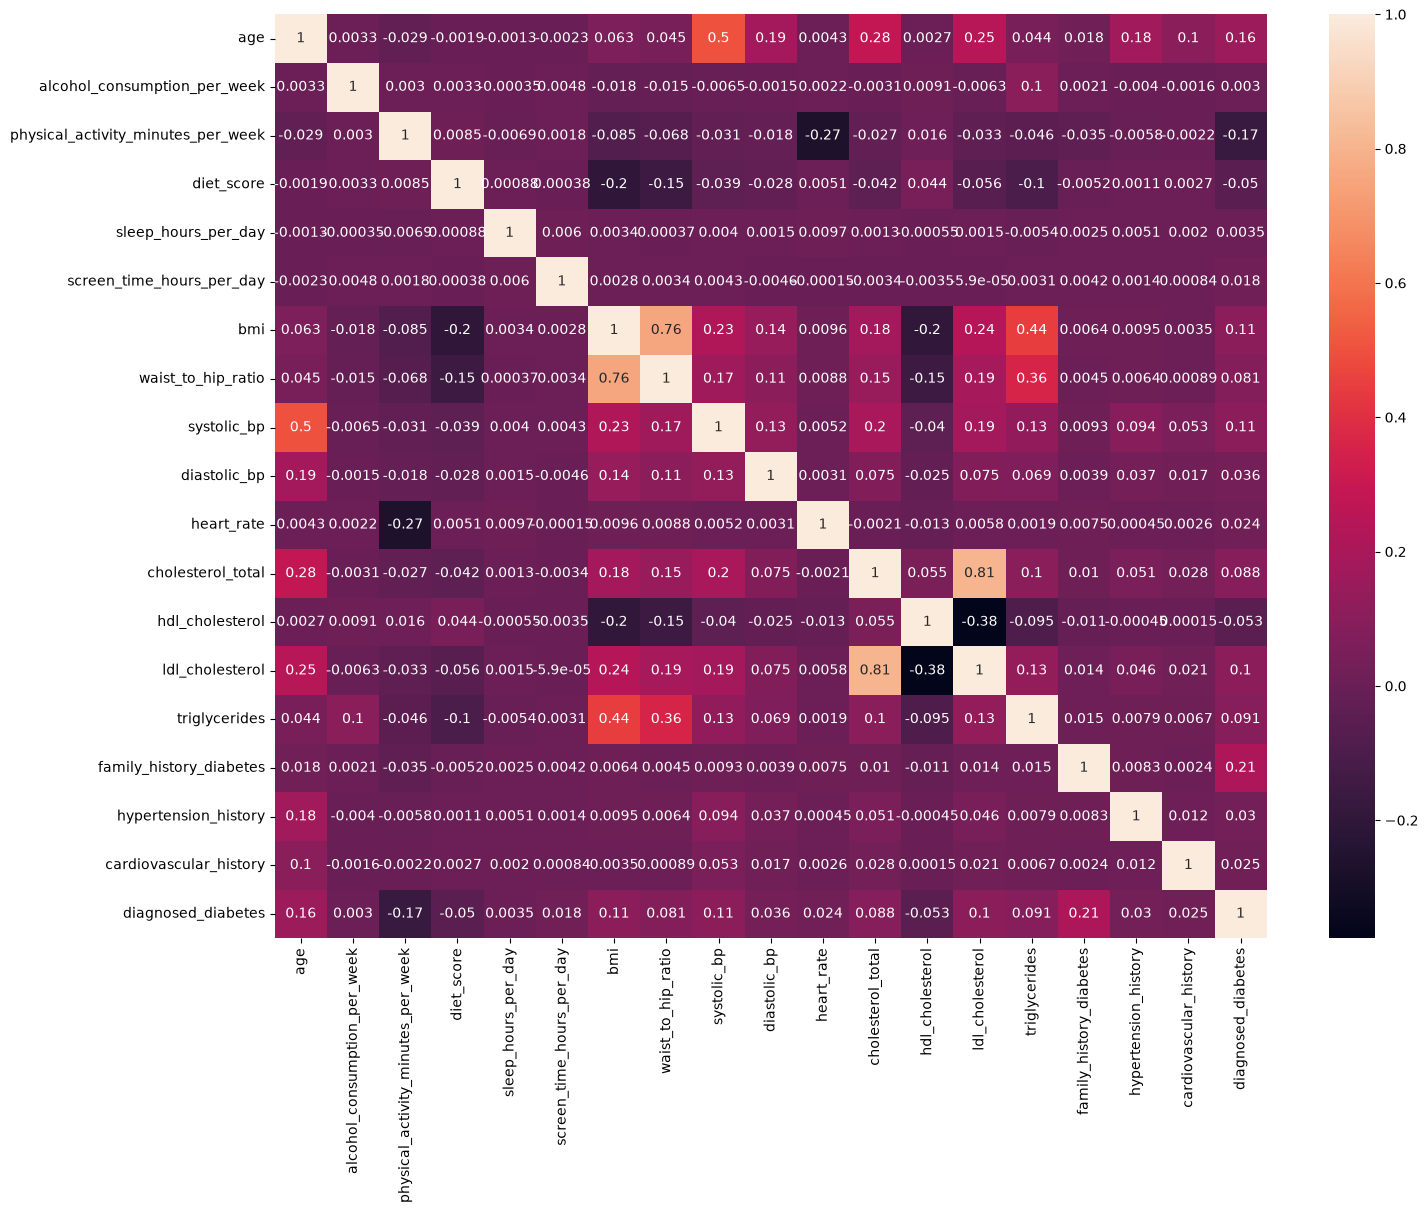

In [15]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## 3. Feature Preparation

Separate numerical and categorical features so they can be processed appropriately.

In [16]:
df.columns  # cheacking all features names

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='str')

In [17]:
# seprating the features
categorical_features = ['gender', 'ethnicity','education_level','income_level','smoking_status', 'employment_status']
numerical_features = ['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides','family_history_diabetes', 'hypertension_history',
       'cardiovascular_history']

## 4. Train–Test Split

Split the data into training and test sets while preserving the target-class distribution.

In [18]:
# making x and y
x = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

In [19]:
# Split into training and validation sets
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.20,random_state= 100,stratify= y)

## 5. Feature Encoding

Scale numerical features and one-hot encode categorical features using one preprocessing pipeline.

**Preprocessing pipeline**  
The same transformations are fitted on the training data and then applied to validation/test data.

In [20]:
# Build preprocessing pipeline for numerical and categorical features
# encoing simulataneously with columntransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_features),
        ('onehot',OneHotEncoder(handle_unknown='ignore'),categorical_features),
    ]
)

In [21]:
# Fit preprocessing only on training data to avoid data leakage
# fitting x_train 
preprocessor.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_nam

In [22]:
# x_train encoding
x_train_encoded = preprocessor.transform(x_train)

# x_test encoding
x_test_encoded = preprocessor.transform(x_test)

In [23]:
# encoding test dataset 
test_encoded = preprocessor.transform(test_df)

## 6. XGBoost Model

Train an XGBoost classifier and search for the selected hyperparameters using ROC-AUC.

**Model tuning**  
ROC-AUC is used as the tuning metric because the project is a binary classification problem.

In [24]:
# Create and tune the XGBoost classifier
xgboost_model = XGBClassifier()
param = {
    'n_estimators' : [10000],
    'max_depth': [3,5],
    'min_child_weight':[5,7],
    'learning_rate': [0.03,0.05],
    'subsample':[0.8],
    'colsample_bytree' :[0.8],
    'n_jobs': [-1]
}
Hrandom_search = HalvingRandomSearchCV(xgboost_model,param,scoring='roc_auc',cv=4,verbose=3)

Hrandom_search.fit(x_train_encoded, y_train)

xg_model = Hrandom_search.best_estimator_

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 10
min_resources_: 16
max_resources_: 560000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 8
n_resources: 16


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=35000. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 4 folds for each of 8 candidates, totalling 32 fits
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.6s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.6s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.8s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  12.4s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.7s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.5s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.6s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.7s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.6s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.4s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.7s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.7s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.4s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.7s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.6s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.7s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.5s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.8s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.8s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  12.0s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.6s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.6s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.8s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  12.2s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.7s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.4s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.8s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.6s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.2s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 2/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.4s


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CV 3/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=nan) total time=  11.8s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.6s
----------
iter: 1
n_candidates: 3
n_resources: 48


c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


Fitting 4 folds for each of 3 candidates, totalling 12 fits
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.7s
[CV 2/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.3s
[CV 3/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.5s
[CV 4/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.4s
[CV 1/4] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=10000, n_jobs=-1, subsample=0.8;, score=(train=0.500, test=0.500) total time=  11.5s
[CV 2/4] E

c:\Users\HARSHIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan 0.5 0.5 0.5]
  warnings.warn(


In [25]:
Hrandom_search.best_estimator_

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
# Generate class predictions for evaluation
y_pred = xg_model.predict(x_test_encoded)

## 7. Model Evaluation

Evaluate classification performance using precision, recall, F1-score, ROC-AUC, and a confusion matrix.

In [27]:
print(classification_report(y_train,xg_model.predict(x_train_encoded)))

              precision    recall  f1-score   support

         0.0       0.65      0.46      0.54    210954
         1.0       0.72      0.85      0.78    349046

    accuracy                           0.70    560000
   macro avg       0.69      0.65      0.66    560000
weighted avg       0.69      0.70      0.69    560000



In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.61      0.44      0.51     52739
         1.0       0.71      0.83      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.64      0.64    140000
weighted avg       0.67      0.68      0.67    140000



**ROC-AUC**  
Use class-1 probabilities because ROC-AUC evaluates how well the model ranks positive cases above negative cases.

In [29]:
y_prob = xg_model.predict_proba(x_test_encoded)[:, 1]
print(roc_auc_score(y_test, y_prob))

0.7282948594136968


In [30]:
# Probability of class 1
train_prob = xg_model.predict_proba(x_train_encoded)[:, 1]
test_prob = xg_model.predict_proba(x_test_encoded)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, train_prob))
print("Test ROC-AUC:", roc_auc_score(y_test, test_prob))

Train ROC-AUC: 0.7545088588081921
Test ROC-AUC: 0.7282948594136968


**Confusion matrix**  
This shows the number of correct and incorrect predictions for each class.

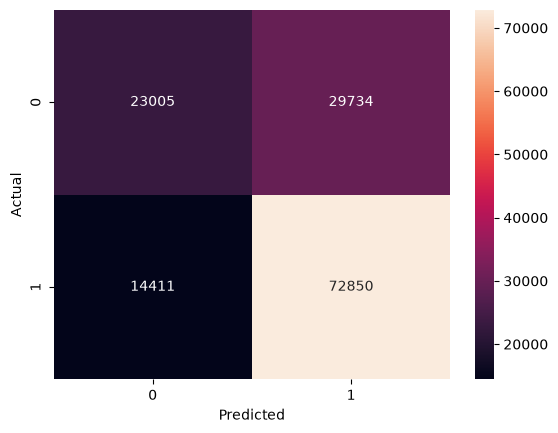

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Model Conclusion
The XGBoost model achieved:

* **Accuracy:** 68%
* **ROC-AUC:** 0.72
* **Diabetes Recall:** 83%

The model shows a reasonable ability to distinguish between patients with and without diabetes, while maintaining relatively high recall for the diabetes class.

Further improvements could be explored through **hyperparameter tuning, feature engineering, and comparison with other classification models**.

Overall, the project demonstrates a complete machine-learning workflow from **data preprocessing to model evaluation**.


## 9. Test Dataset Prediction

Use the trained model to generate predictions and class-1 probabilities for the separate test dataset.

**Generate test predictions**  
Create the final class predictions for the external test dataset.

In [47]:
test_predictions = xg_model.predict(test_encoded)

In [48]:
# Get probability of the positive class (diabetes = 1)
test_probabilities = xg_model.predict_proba(test_encoded)[:, 1]

In [50]:
# submission = pd.DataFrame({'diagnosed_diabetes': test_predictions})
submission = pd.DataFrame({'id': test_ids, 'diagnosed_diabetes': test_predictions})

In [52]:
submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


## 10. Final Takeaway

The project covers the main machine-learning workflow:

**EDA → preprocessing → model training → evaluation → test prediction**

The next improvement would be stronger hyperparameter tuning and model interpretation.